In [14]:
import torch 
import torch.nn as nn 
import torch.optim as optim 
from torch.optim import AdamW
from PIL import Image
from torch.utils.data import DataLoader, Dataset 
from torchvision import datasets, transforms, models 
from torchvision.models import MobileNet_V2_Weights
from transformers import DistilBertModel, DistilBertTokenizer
import numpy as np 
import re
import os 
import matplotlib.pyplot as plt
import cv2
import matplotlib.pyplot as plt 
from sklearn.metrics import confusion_matrix 
import seaborn as sns 

# Change these as appropriate 
test_dir = "CVPR_2024_datasetTest"
best_model_pth = 'best_model_MMM.pth'

In [15]:
# Function to obtain texts, targets, and filenames, heavily influenced by the example text extractor in class example 
def read_text_files_with_labels(path):
    # Setting up arrays for obtaining features and targets, and as an addition, grabbing file paths for images as well, this will come in handy for the dataset 
    texts = []
    labels = []
    fn_arr = [] 

    # Obtaining classes 
    class_folders = sorted(sorted(os.listdir(path)))

    # Effectively encoding the class file names to numbers 
    label_map = {class_name: idx for idx, class_name in enumerate(class_folders)}

    # This parses the files and correlates targets to features as well as grabs filename outputs 
    for class_name in class_folders:
        class_path = os.path.join(path,class_name)
        if os.path.isdir(class_path):
            file_names = os.listdir(class_path)
            for file_name in file_names:
                file_path = os.path.join(class_path, file_name)
                if os.path.isfile(file_path):
                    file_name_no_ext, _ = os.path.splitext(file_name)
                    text = file_name_no_ext.replace('_',' ')
                    text_without_digits = re.sub(r'\d+','',text)
                    texts.append(text_without_digits)
                    labels.append(label_map[class_name])
                    fn_arr.append(os.path.join(class_path,file_name))

    return np.array(texts), np.array(labels), np.array(fn_arr)

# Batch prediction loop function heavily inspired by in class example 
def predict(model,dataloader,device):
    model.eval()
    predictions = []
    print('Making predictions...')
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images = batch['image'].to(device) 

            outputs = model(input_ids,attention_mask,images)
            _, preds = torch.max(outputs, dim=1)

            predictions.extend(preds.cpu().numpy())

    return predictions 

# Function for making single prediction on a model, useful to individual debugging or for final prediction outputs 
def predict_single_image(model, image_path, tokenizer, transform, device, class_folders):
    # First is data preparation, I'm sure there is a better way to do this but I am effectively repeating the steps found in the custom dataset/ file prep function I used during training 
    # Extract the text label 
    file_name = os.path.basename(image_path)
    file_name_no_ext, _ = os.path.splitext(file_name)
    text = file_name_no_ext.replace('_', ' ')
    text = re.sub(r'\d+', '', text)
    
    # Load the image and transform, MUST add the batch dim otherwise error 
    image = Image.open(image_path).convert('RGB')
    image = transform(image)
    image = image.unsqueeze(0).to(device) # Batch dim 

    # Create tokenizer 
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=24,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    # Obtain the necessary inputs for the text model 
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    # Actual prediction, set model to eval mode, do not compute gradient 
    model.eval()
    with torch.no_grad():
        outputs = model(input_ids, attention_mask, image)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(probs, dim=1)
    predicted_class = class_folders[predicted.item()]

    # Returning the predicted class as well as the label for comparison with the real class and image 
    return predicted_class, text



# Custom dataset for prepping data to be input into a combined text and image based model architecture 
class CustomDataset(Dataset):
    def __init__(self, dir, fns, texts, labels, tokenizer, transform):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = 24
        self.dir = dir 
        self.fns = fns 
        self.transform = transform 

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        im_path = self.fns[idx]
        image = Image.open(im_path).convert('RGB')

        image = self.transform(image)

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long),
            'image': image
        }

# MultiModal Model custom built for task 
class MMM(nn.Module):
    def __init__(self):
        super(MMM,self).__init__() 

        # Load the pretrained text and image models 
        self.text_model = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.image_model = models.mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)

        # Freeze all parameters to start with a known slate 
        for param in self.text_model.parameters():
            param.requires_grad = False 
        for param in self.image_model.features.parameters():
            param.requires_grad = False 

        # Unfreeze the specific layers you want to train within the pretrained models 
        #   Unfreezing last 2 layers from each model, determined to be sufficient empirically 
        for param in self.image_model.features[-2:].parameters():
            param.requires_grad = True
        for layer in self.text_model.transformer.layer[-2:]:
            for param in layer.parameters():
                param.requires_grad = True

        # Remove image classifier 
        self.image_num_features = self.image_model.classifier[1].in_features 
        self.image_model.classifier = nn.Identity() 

        # Do not need to remove classifier for DistilBERT because it does not have a head on the base model! 
        self.text_num_features = self.text_model.config.hidden_size 

        # Project vectors to the same size to avoid over-reliance on a single model 
        self.text_proj = nn.Linear(self.text_num_features,256)
        self.image_proj = nn.Linear(self.image_num_features,256)

        # Create a fully connected head 
        self.fc = nn.Sequential(
            nn.Linear(512, 256), 
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 4) # Final output layer
        )
    
    def forward(self,input_ids,attention_mask, images):
        # Obtain output vector from the text model and normalize 
        text_output = self.text_model(input_ids=input_ids,attention_mask=attention_mask)
        text_embeddings = text_output.last_hidden_state[:,0,:]
        text_embeddings = self.text_proj(text_embeddings)
        text_embeddings = nn.functional.normalize(text_embeddings,p=2,dim=1)

        # Obtain output vector from the image model and normalize 
        image_embeddings = self.image_model(images)
        image_embeddings = self.image_proj(image_embeddings)
        image_embeddings = nn.functional.normalize(image_embeddings,p=2,dim=1)

        # Concatenate the normalized output from each model into one and send to the fully connected head layer
        combined = torch.cat((text_embeddings,image_embeddings),dim=1)
        
        output = self.fc(combined)

        return output 


In [16]:
# Build the testing datasets/dataloaders 
text_test,labels_test,fns_test = read_text_files_with_labels(test_dir) 

# Build the transform for images
transform_test = transforms.Compose([transforms.Resize((224,224)),
                                transforms.ToTensor(),
                                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.255])])

# Grab tokenizer from DistilBert 
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Build datasets, essentially it feeds the raw data into their respective trasnsforms and preps in for model consumption 
test_dataset = CustomDataset(test_dir, fns_test, text_test, labels_test, tokenizer, transform_test) 

# Build dataloaders, wraps data in iterator to utilize batches and convenient shuffling 
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

# Choose GPU if available 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 

# Create model and send to the computation device 
model = MMM() 
model = model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Making predictions...
Accuracy: 0.8450


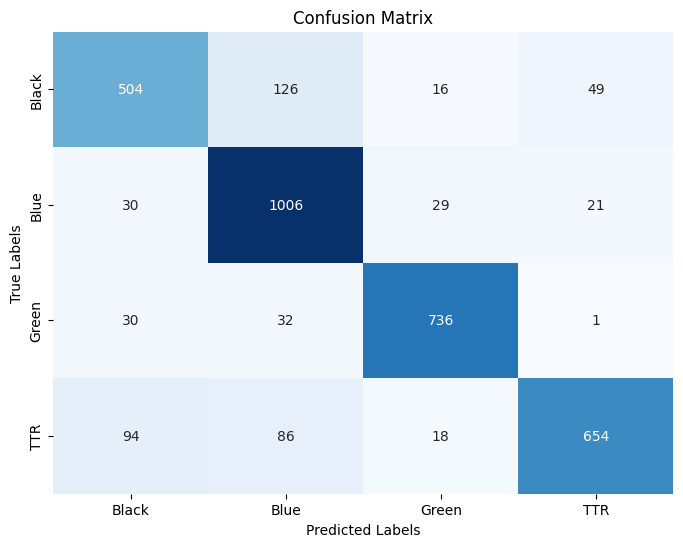

In [17]:
# Run batch prediction and determine model test accuracy 
model.load_state_dict(torch.load(best_model_pth))
test_predictions = predict(model,test_dataloader,device)
print(f'Accuracy: {(test_predictions == labels_test).sum()/labels_test.size:.4f}')

# Confusion matrix to visualize precision and recall as well as any preference for classes 
cm = confusion_matrix(labels_test, test_predictions) 

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,xticklabels=['Black','Blue','Green','TTR'],yticklabels=['Black','Blue','Green','TTR'],cmap='Blues',fmt='g',cbar=False)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show() 

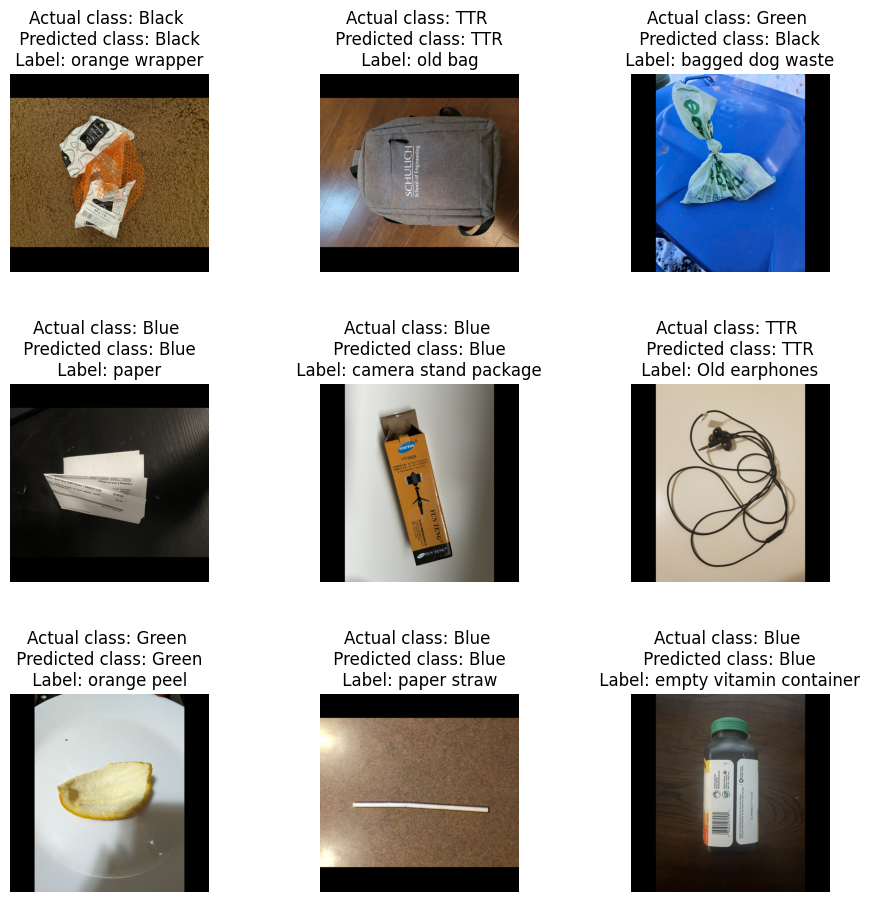

In [18]:
# Building grid of predictions for visualization 
class_folders = ['Black','Blue','Green','TTR']
im_array = np.random.randint(len(fns_test),size=9)
images = [] 
labels = [] 
for index in range(len(im_array)):
    image_test = fns_test[im_array[index]]
    actual_class = image_test.split('\\')[1]
    pred_class,text = predict_single_image(model,image_test,tokenizer,transform_test,device,class_folders)

    img = cv2.imread(image_test)
    img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    images.append(img_rgb)
    labels.append(f'Actual class: {actual_class} \n Predicted class: {pred_class} \n Label: {text}')

fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize=(10,10))
plt.tight_layout(pad=5.0) 

for ax,img,lbl in zip(axes.flatten(),images,labels):
    ax.imshow(img)
    ax.set_title(lbl)
    ax.axis('off')
plt.show()
